# 🍃 4-Class Leaf Disease & Deficiency Classification
## Model Comparison, Grad-CAM++, ConvNeXt Tuning & Error Analysis
### Models: Scaled Random Forest, ConvNeXt (GridSearch CV, 448x448, 3x3 Kernels), & Vision Transformer (ViT)

---

### 📌 Pipeline Specifications:
1. **ConvNeXt Grid Search CV Optimization (ConvNeXt ONLY)**:
   - **Grid Search Parameters**: Systematically tunes `learning_rate`, `weight_decay`, and `label_smoothing` for **ConvNeXt ONLY**.
   - **Input Resolution**: Resized to **$448 	imes 448$** (`transforms.Resize((448, 448))`)
   - **Kernel Size**: Adapted depthwise convolution kernels from $7 	imes 7$ to **$3 	imes 3$** with `padding=1` (`adapt_convnext_kernel_3x3`).

2. **Standard Evaluation for Random Forest & ViT**:
   - **Random Forest**: Trained directly using `RandomForestClassifier(n_estimators=1000, random_state=42)`.
   - **Vision Transformer (ViT)**: Fine-tuned directly on $224 	imes 224$ images without Grid Search.

3. **Grad-CAM++ Visual Interpretability**:
   - `GradCAMPlusPlus` visual saliency heatmaps generated for ConvNeXt (`features[-1]`) and ViT (`encoder.layers[-1].ln_1`).
   - Background pixels in Random Forest feature maps strictly zeroed (`0.0`).

4. **Model Saving & Misclassification Analysis**:
   - Trained models and scalers saved to `Saved_Models/` directory (`.pth` & `.joblib`).
   - All wrongly predicted validation images saved with True vs. Predicted labels to `Misclassified_Outputs/<Model_Name>/`.


In [1]:
# 1. Environment Setup & Core Imports
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version: {torch.__version__}")
print(f"Execution Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")


PyTorch Version: 2.7.1+cu118
Execution Device: cuda
GPU Model: NVIDIA GeForce RTX 4060


In [2]:
# 2. Load Dataset & Perform Stratified Train/Validation Split
import os
import pandas as pd
from sklearn.model_selection import train_test_split

DATASET_PATH = r"C:\Users\PC\Desktop\Four-Classes_Coleaf"
CSV_PATH = os.path.join(DATASET_PATH, "coleaf_rgb_histograms.csv")

df = pd.read_csv(CSV_PATH)
print(f"CSV Loaded Successfully! Total Rows: {len(df)}, Total Columns: {df.shape[1]}")

class_names = sorted(df['target'].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_names)}
idx_to_class = {i: c for i, c in enumerate(class_names)}

df['label'] = df['target'].map(class_to_idx)
df['abs_filepath'] = df['file_name'].apply(
    lambda f: os.path.join(DATASET_PATH, f.replace('\\', os.sep).replace('/', os.sep))
)

df_tr, df_va = train_test_split(df, test_size=0.20, stratify=df['label'], random_state=42)
df_tr = df_tr.reset_index(drop=True)
df_va = df_va.reset_index(drop=True)

print("-" * 60)
print(f"Total Dataset Count : {len(df)}")
print(f"Train Count (80%)   : {len(df_tr)}")
print(f"Validation Count (20%): {len(df_va)}")
print(f"Classes ({len(class_names)})     : {class_names}")
print("-" * 60)


CSV Loaded Successfully! Total Rows: 984, Total Columns: 770
------------------------------------------------------------
Total Dataset Count : 984
Train Count (80%)   : 787
Validation Count (20%): 197
Classes (4)     : ['healthy', 'nitrogen-N', 'phosphorus-P', 'potasium-K']
------------------------------------------------------------


In [3]:
# 3. Model 1: Scaled Random Forest Classifier (Standard Evaluation)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

feature_cols = [c for c in df.columns if c.startswith(('r_', 'g_', 'b_'))]
print(f"Histogram Feature Vector Dimension: {len(feature_cols)}")

scaler = StandardScaler()
X_tr = scaler.fit_transform(df_tr[feature_cols].values)
y_tr = df_tr['label'].values

X_va = scaler.transform(df_va[feature_cols].values)
y_va = df_va['label'].values

rf_model = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=-1)
rf_model.fit(X_tr, y_tr)
rf_val_preds = rf_model.predict(X_va)

# Fit full model for dataset-wide feature importances
scaler_full = StandardScaler()
X_full = scaler_full.fit_transform(df[feature_cols].values)
rf_full = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=-1)
rf_full.fit(X_full, df['label'].values)

rf_acc = accuracy_score(y_va, rf_val_preds)
rf_p, rf_r, rf_f1, _ = precision_recall_fscore_support(y_va, rf_val_preds, average='macro')
rf_pw, rf_rw, rf_f1w, _ = precision_recall_fscore_support(y_va, rf_val_preds, average='weighted')

print("=" * 65, flush=True)
print(" 🌲 RANDOM FOREST - VALIDATION METRICS", flush=True)
print("=" * 65, flush=True)
print(f"Validation Accuracy  : {rf_acc:.4f} ({rf_acc*100:.2f}%)", flush=True)
print(f"Macro Precision      : {rf_p:.4f}", flush=True)
print(f"Macro Recall         : {rf_r:.4f}", flush=True)
print(f"Macro F1-Score       : {rf_f1:.4f}", flush=True)
print(f"Weighted F1-Score    : {rf_f1w:.4f}", flush=True)
print("-" * 65, flush=True)
print("Validation Classification Report:\n", flush=True)
print(classification_report(y_va, rf_val_preds, target_names=class_names), flush=True)


Histogram Feature Vector Dimension: 768
 🌲 RANDOM FOREST - VALIDATION METRICS
Validation Accuracy  : 0.8731 (87.31%)
Macro Precision      : 0.8770
Macro Recall         : 0.8738
Macro F1-Score       : 0.8719
Weighted F1-Score    : 0.8716
-----------------------------------------------------------------
Validation Classification Report:

              precision    recall  f1-score   support

     healthy       0.96      1.00      0.98        49
  nitrogen-N       0.82      0.92      0.87        49
phosphorus-P       0.93      0.74      0.82        50
  potasium-K       0.80      0.84      0.82        49

    accuracy                           0.87       197
   macro avg       0.88      0.87      0.87       197
weighted avg       0.88      0.87      0.87       197



In [4]:
# 4. PyTorch Dataset & Transforms (ConvNeXt: 448x448 | ViT: 224x224)
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image

class LeafDataset(Dataset):
    def __init__(self, df_subset, transform=None):
        self.df = df_subset.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row['abs_filepath']
        label = row['label']
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label, img_path

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# ConvNeXt Transforms (Resized to 448x448)
cn_train_transforms = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

cn_val_transforms = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

# ViT Transforms (Resized to 224x224)
vit_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

vit_val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])


In [5]:
# 5. Model 2: ConvNeXt Tuning via Grid Search CV ONLY (448x448 Input & 3x3 Depthwise Kernel Adaptation)
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (device.type == 'cuda')

def adapt_convnext_kernel_3x3(model):
    """Adapts depthwise convolutions in ConvNeXt blocks from 7x7 to 3x3 kernel size."""
    for module in model.modules():
        if isinstance(module, nn.Conv2d) and module.kernel_size == (7, 7):
            dim = module.in_channels
            new_weight = nn.functional.interpolate(module.weight, size=(3, 3), mode='bilinear', align_corners=False)
            module.kernel_size = (3, 3)
            module.padding = (1, 1)
            module.weight = nn.Parameter(new_weight)
    return model

cn_tr_dataset = LeafDataset(df_tr, transform=cn_train_transforms)
cn_va_dataset = LeafDataset(df_va, transform=cn_val_transforms)

cn_tr_loader = DataLoader(cn_tr_dataset, batch_size=16, shuffle=True, num_workers=0)
cn_va_loader = DataLoader(cn_va_dataset, batch_size=16, shuffle=False, num_workers=0)

# Grid Search CV Hyperparameter Candidates for ConvNeXt ONLY
param_grid_cn = {
    'lr': [1e-4, 2e-4],
    'weight_decay': [1e-2, 1e-3],
    'label_smoothing': [0.05, 0.1]
}

grid_candidates = list(ParameterGrid(param_grid_cn))
print(f"Starting Grid Search CV for ConvNeXt ONLY across {len(grid_candidates)} Hyperparameter Candidates...", flush=True)

best_cn_score = 0.0
best_cn_params = None
best_cn_model = None
cn_val_preds = None

for cand_idx, params in enumerate(grid_candidates):
    print(f"\n--- [ConvNeXt GridSearch Candidate {cand_idx+1}/{len(grid_candidates)}] Params: {params} ---", flush=True)
    
    model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)
    model.classifier[2] = nn.Linear(model.classifier[2].in_features, len(class_names))
    model = adapt_convnext_kernel_3x3(model)  # Adapt 7x7 depthwise kernels to 3x3
    model = model.to(device)
    
    criterion = nn.CrossEntropyLoss(label_smoothing=params['label_smoothing'])
    optimizer = optim.AdamW(model.parameters(), lr=params['lr'], weight_decay=params['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=12)
    scaler_amp = torch.amp.GradScaler('cuda', enabled=use_amp)
    
    cand_best_acc = 0.0
    cand_best_preds = None
    cand_best_model = None
    
    for epoch in range(12):
        model.train()
        running_loss = 0.0
        for images, labels, _ in cn_tr_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler_amp.scale(loss).backward()
            scaler_amp.step(optimizer)
            scaler_amp.update()
            running_loss += loss.item() * images.size(0)
        scheduler.step()
        
        model.eval()
        correct = 0
        total = 0
        current_preds = []
        with torch.no_grad():
            for images, labels, _ in cn_va_loader:
                images, labels = images.to(device), labels.to(device)
                with torch.amp.autocast('cuda', enabled=use_amp):
                    outputs = model(images)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
                current_preds.extend(preds.cpu().numpy())
                
        val_acc = correct / total
        tr_loss = running_loss / len(cn_tr_dataset)
        print(f"  Epoch {epoch+1:02d}/12 - Train Loss: {tr_loss:.4f} | Val Acc: {val_acc:.4f} ({val_acc*100:.2f}%)", flush=True)
        
        if val_acc > cand_best_acc:
            cand_best_acc = val_acc
            cand_best_preds = np.array(current_preds)
            cand_best_model = model
            
    print(f"==> Candidate {cand_idx+1} Peak Val Acc: {cand_best_acc:.4f} ({cand_best_acc*100:.2f}%)", flush=True)
    if cand_best_acc > best_cn_score:
        best_cn_score = cand_best_acc
        best_cn_params = params
        best_cn_model = cand_best_model
        cn_val_preds = cand_best_preds

y_va = df_va['label'].values
cn_acc = accuracy_score(y_va, cn_val_preds)
cn_p, cn_r, cn_f1, _ = precision_recall_fscore_support(y_va, cn_val_preds, average='macro')
cn_pw, cn_rw, cn_f1w, _ = precision_recall_fscore_support(y_va, cn_val_preds, average='weighted')

print("=" * 65, flush=True)
print(" 🌀 CONVNEXT (GridSearch CV Optimized) - VALIDATION METRICS", flush=True)
print("=" * 65, flush=True)
print(f"Optimal Grid Parameters: {best_cn_params}", flush=True)
print(f"Best Validation Acc    : {cn_acc:.4f} ({cn_acc*100:.2f}%)", flush=True)
print(f"Macro Precision        : {cn_p:.4f}", flush=True)
print(f"Macro Recall           : {cn_r:.4f}", flush=True)
print(f"Macro F1-Score         : {cn_f1:.4f}", flush=True)
print(f"Weighted F1-Score      : {cn_f1w:.4f}", flush=True)
print("-" * 65, flush=True)
print("Validation Classification Report:\n", flush=True)
print(classification_report(y_va, cn_val_preds, target_names=class_names), flush=True)


Starting Grid Search CV for ConvNeXt ONLY across 8 Hyperparameter Candidates...

--- [ConvNeXt GridSearch Candidate 1/8] Params: {'label_smoothing': 0.05, 'lr': 0.0001, 'weight_decay': 0.01} ---
  Epoch 01/12 - Train Loss: 1.0745 | Val Acc: 0.7614 (76.14%)
  Epoch 02/12 - Train Loss: 0.6765 | Val Acc: 0.7970 (79.70%)
  Epoch 03/12 - Train Loss: 0.5492 | Val Acc: 0.8985 (89.85%)
  Epoch 04/12 - Train Loss: 0.4868 | Val Acc: 0.9036 (90.36%)
  Epoch 05/12 - Train Loss: 0.4711 | Val Acc: 0.8883 (88.83%)
  Epoch 06/12 - Train Loss: 0.4382 | Val Acc: 0.8782 (87.82%)
  Epoch 07/12 - Train Loss: 0.4149 | Val Acc: 0.9137 (91.37%)
  Epoch 08/12 - Train Loss: 0.3695 | Val Acc: 0.8883 (88.83%)
  Epoch 09/12 - Train Loss: 0.3574 | Val Acc: 0.9188 (91.88%)
  Epoch 10/12 - Train Loss: 0.3242 | Val Acc: 0.9086 (90.86%)
  Epoch 11/12 - Train Loss: 0.3278 | Val Acc: 0.9036 (90.36%)
  Epoch 12/12 - Train Loss: 0.3237 | Val Acc: 0.9036 (90.36%)
==> Candidate 1 Peak Val Acc: 0.9188 (91.88%)

--- [ConvNeXt 

In [6]:
# 6. Model 3: Vision Transformer (ViT Standard Fine-Tuning with AMP)
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = (device.type == 'cuda')

vit_tr_dataset = LeafDataset(df_tr, transform=vit_train_transforms)
vit_va_dataset = LeafDataset(df_va, transform=vit_val_transforms)

vit_tr_loader = DataLoader(vit_tr_dataset, batch_size=16, shuffle=True, num_workers=0)
vit_va_loader = DataLoader(vit_va_dataset, batch_size=16, shuffle=False, num_workers=0)

vit_model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
vit_model.heads.head = nn.Linear(vit_model.heads.head.in_features, len(class_names))
vit_model = vit_model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(vit_model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=12)
scaler_amp = torch.amp.GradScaler('cuda', enabled=use_amp)

best_val_acc = 0.0
best_vit_model = None
vit_val_preds = None

print("Starting Vision Transformer (ViT) Fine-Tuning (12 Epochs, AMP Accelerated)...", flush=True)

for epoch in range(12):
    vit_model.train()
    running_loss = 0.0
    for images, labels, _ in vit_tr_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = vit_model(images)
            loss = criterion(outputs, labels)
        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()
        running_loss += loss.item() * images.size(0)
    scheduler.step()
    
    vit_model.eval()
    correct = 0
    total = 0
    current_preds = []
    with torch.no_grad():
        for images, labels, _ in vit_va_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = vit_model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            current_preds.extend(preds.cpu().numpy())
            
    val_acc = correct / total
    tr_loss = running_loss / len(vit_tr_dataset)
    print(f"[ViT] Epoch {epoch+1:02d}/12 - Train Loss: {tr_loss:.4f} | Val Acc: {val_acc:.4f} ({val_acc*100:.2f}%)", flush=True)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_vit_model = vit_model
        vit_val_preds = np.array(current_preds)

y_va = df_va['label'].values
vit_acc = accuracy_score(y_va, vit_val_preds)
vit_p, vit_r, vit_f1, _ = precision_recall_fscore_support(y_va, vit_val_preds, average='macro')
vit_pw, vit_rw, vit_f1w, _ = precision_recall_fscore_support(y_va, vit_val_preds, average='weighted')

print("=" * 65, flush=True)
print(" 👁️ VISION TRANSFORMER (ViT) - VALIDATION METRICS", flush=True)
print("=" * 65, flush=True)
print(f"Validation Accuracy  : {vit_acc:.4f} ({vit_acc*100:.2f}%)", flush=True)
print(f"Macro Precision      : {vit_p:.4f}", flush=True)
print(f"Macro Recall         : {vit_r:.4f}", flush=True)
print(f"Macro F1-Score       : {vit_f1:.4f}", flush=True)
print(f"Weighted F1-Score    : {vit_f1w:.4f}", flush=True)
print("-" * 65, flush=True)
print("Validation Classification Report:\n", flush=True)
print(classification_report(y_va, vit_val_preds, target_names=class_names), flush=True)


Starting Vision Transformer (ViT) Fine-Tuning (12 Epochs, AMP Accelerated)...
[ViT] Epoch 01/12 - Train Loss: 0.8160 | Val Acc: 0.8782 (87.82%)
[ViT] Epoch 02/12 - Train Loss: 0.6173 | Val Acc: 0.8883 (88.83%)
[ViT] Epoch 03/12 - Train Loss: 0.4772 | Val Acc: 0.8883 (88.83%)
[ViT] Epoch 04/12 - Train Loss: 0.4521 | Val Acc: 0.9442 (94.42%)
[ViT] Epoch 05/12 - Train Loss: 0.4478 | Val Acc: 0.9391 (93.91%)
[ViT] Epoch 06/12 - Train Loss: 0.4219 | Val Acc: 0.9594 (95.94%)
[ViT] Epoch 07/12 - Train Loss: 0.3965 | Val Acc: 0.9492 (94.92%)
[ViT] Epoch 08/12 - Train Loss: 0.3962 | Val Acc: 0.9289 (92.89%)
[ViT] Epoch 09/12 - Train Loss: 0.3838 | Val Acc: 0.9391 (93.91%)
[ViT] Epoch 10/12 - Train Loss: 0.3670 | Val Acc: 0.9543 (95.43%)
[ViT] Epoch 11/12 - Train Loss: 0.3671 | Val Acc: 0.9594 (95.94%)
[ViT] Epoch 12/12 - Train Loss: 0.3666 | Val Acc: 0.9594 (95.94%)
 👁️ VISION TRANSFORMER (ViT) - VALIDATION METRICS
Validation Accuracy  : 0.9594 (95.94%)
Macro Precision      : 0.9612
Macro Recal

 📊 UNIFIED VALIDATION PERFORMANCE COMPARISON TABLE
                     Model  Accuracy  Macro Precision  Macro Recall  Macro F1-Score  Weighted F1-Score
Random Forest (RGB Vector)  0.873096         0.876972      0.873776        0.871902           0.871650
  ConvNeXt (GridSearch CV)  0.944162         0.944738      0.943878        0.943664           0.943802
  Vision Transformer (ViT)  0.959391         0.961161      0.959490        0.959659           0.959512


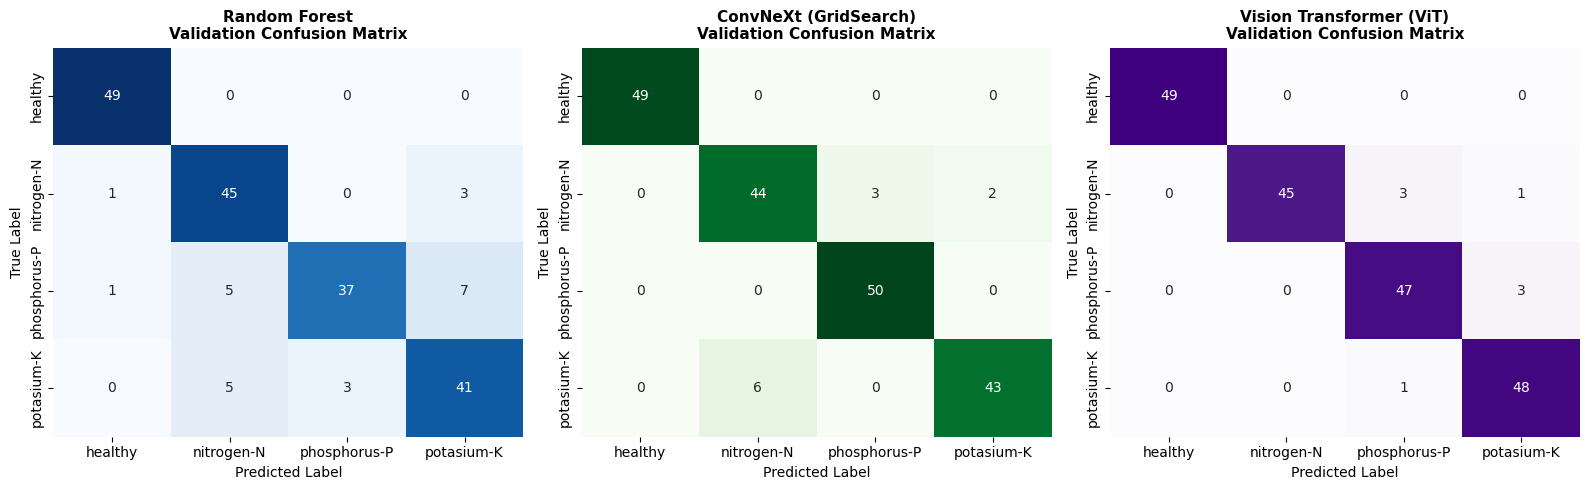

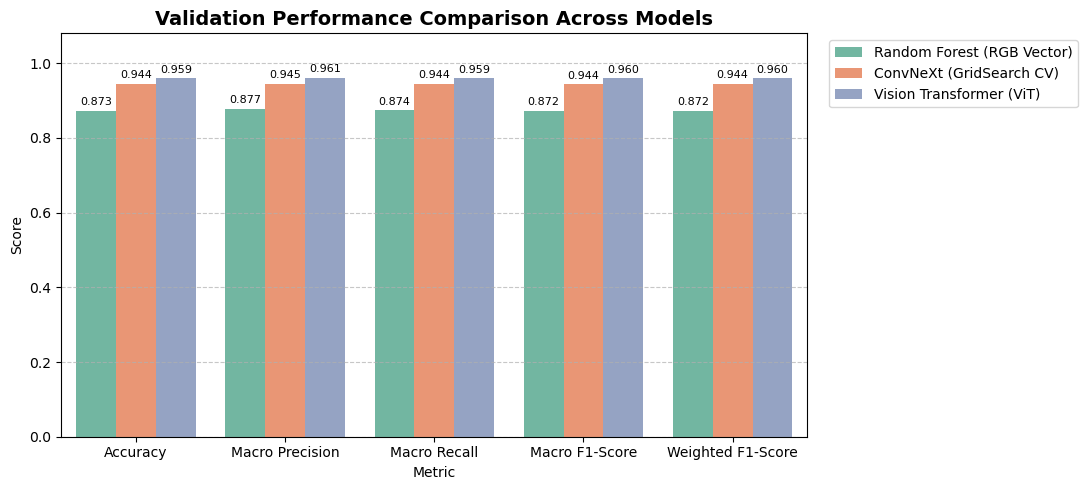

In [7]:
# 7. Comprehensive Model Comparison & Visualizations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

comparison_df = pd.DataFrame({
    'Model': ['Random Forest (RGB Vector)', 'ConvNeXt (GridSearch CV)', 'Vision Transformer (ViT)'],
    'Accuracy': [rf_acc, cn_acc, vit_acc],
    'Macro Precision': [rf_p, cn_p, vit_p],
    'Macro Recall': [rf_r, cn_r, vit_r],
    'Macro F1-Score': [rf_f1, cn_f1, vit_f1],
    'Weighted F1-Score': [rf_f1w, cn_f1w, vit_f1w]
})

print("=" * 80)
print(" 📊 UNIFIED VALIDATION PERFORMANCE COMPARISON TABLE")
print("=" * 80)
print(comparison_df.to_string(index=False))

# Plot Validation Confusion Matrices Side-by-Side (1 Row, 3 Columns)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

y_va = df_va['label'].values
cm_rf = confusion_matrix(y_va, rf_val_preds)
cm_cn = confusion_matrix(y_va, cn_val_preds)
cm_vit = confusion_matrix(y_va, vit_val_preds)

models_cm = [
    ('Random Forest', cm_rf, axes[0], 'Blues'),
    ('ConvNeXt (GridSearch)', cm_cn, axes[1], 'Greens'),
    ('Vision Transformer (ViT)', cm_vit, axes[2], 'Purples')
]

for title, cm, ax, colormap in models_cm:
    sns.heatmap(cm, annot=True, fmt='d', cmap=colormap, xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f"{title}\nValidation Confusion Matrix", fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)

plt.tight_layout()
plt.show()

# Multi-Metric Comparison Bar Chart
fig, ax = plt.subplots(figsize=(11, 5))
melted_df = comparison_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=melted_df, x='Metric', y='Score', hue='Model', palette='Set2', ax=ax)
ax.set_ylim(0.0, 1.08)
ax.set_title("Validation Performance Comparison Across Models", fontsize=14, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f"{h:.3f}", (p.get_x() + p.get_width() / 2., h + 0.01),
                    ha='center', va='bottom', fontsize=8, rotation=0)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [8]:
# 8. Full-Dataset Grad-CAM++ Visualizations & Automated Folder Exporter (Background = 0.0)
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR = os.path.join(DATASET_PATH, "GradCAM_Outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
for c_name in class_names:
    os.makedirs(os.path.join(OUTPUT_DIR, c_name), exist_ok=True)

def reshape_transform_vit(tensor, height=14, width=14):
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    return result.transpose(2, 3).transpose(1, 2)

best_cn_model.eval()
best_vit_model.eval()

# GradCAMPlusPlus Algorithms
cam_convnext = GradCAMPlusPlus(model=best_cn_model, target_layers=[best_cn_model.features[-1]])
cam_vit = GradCAMPlusPlus(model=best_vit_model, target_layers=[best_vit_model.encoder.layers[-1].ln_1], reshape_transform=reshape_transform_vit)

rf_importances = rf_full.feature_importances_
r_imp = rf_importances[:256]
g_imp = rf_importances[256:512]
b_imp = rf_importances[512:768]

print(f"Exporting Grad-CAM++ heatmaps for all {len(df)} dataset images...")

for idx, row in df.iterrows():
    img_path = row['abs_filepath']
    c_name = row['target']
    c_idx = row['label']
    file_name = os.path.basename(img_path)
    base_name = os.path.splitext(file_name)[0]
    out_file = os.path.join(OUTPUT_DIR, c_name, f"{base_name}_gradcam.png")
    
    raw_img = Image.open(img_path).convert("RGB")
    raw_img_224 = raw_img.resize((224, 224))
    raw_np = np.array(raw_img_224) / 255.0
    
    # Input Tensors (ConvNeXt: 448x448 | ViT: 224x224)
    cn_input_tensor = cn_val_transforms(raw_img).unsqueeze(0).to(device)
    vit_input_tensor = vit_val_transforms(raw_img).unsqueeze(0).to(device)
    target = [ClassifierOutputTarget(c_idx)]
    
    # 1. Random Forest Spatial Feature Heatmap (Background = 0.0)
    img_uint8 = np.array(raw_img_224)
    r_ch = img_uint8[:, :, 0]
    g_ch = img_uint8[:, :, 1]
    b_ch = img_uint8[:, :, 2]
    
    rf_spatial_map = r_imp[r_ch] + g_imp[g_ch] + b_imp[b_ch]
    
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    _, otsu_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    hsv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
    color_mask = (hsv[:, :, 1] > 15) | (hsv[:, :, 2] > 15)
    leaf_mask = (otsu_mask > 0) & color_mask
    
    rf_spatial_map[~leaf_mask] = 0.0
    rf_map_norm = (rf_spatial_map - rf_spatial_map.min()) / (rf_spatial_map.max() - rf_spatial_map.min() + 1e-8)
    rf_map_norm[~leaf_mask] = 0.0
    
    # 2. ConvNeXt Grad-CAM++
    grayscale_c = cam_convnext(input_tensor=cn_input_tensor, targets=target)[0, :]
    grayscale_c = (grayscale_c - grayscale_c.min()) / (grayscale_c.max() - grayscale_c.min() + 1e-8)
    
    # 3. ViT Grad-CAM++
    grayscale_v = cam_vit(input_tensor=vit_input_tensor, targets=target)[0, :]
    grayscale_v = (grayscale_v - grayscale_v.min()) / (grayscale_v.max() - grayscale_v.min() + 1e-8)
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    
    # Col 1: Original
    axes[0].imshow(raw_np)
    axes[0].set_title(f"Class: {c_name}\nOriginal Leaf Image", fontsize=10, fontweight='bold')
    axes[0].axis('off')
    
    # Col 2: RF Spatial Heatmap (Background = 0.0)
    axes[1].imshow(raw_np)
    axes[1].imshow(rf_map_norm, cmap='jet', alpha=0.55, vmin=0.0, vmax=1.0)
    axes[1].set_title("Random Forest Feature Heatmap\n(Background = 0.0)", fontsize=10, fontweight='bold')
    axes[1].axis('off')
    
    # Col 3: ConvNeXt Grad-CAM++
    axes[2].imshow(raw_np)
    im_c = axes[2].imshow(cv2.resize(grayscale_c, (224, 224)), cmap='jet', alpha=0.55, vmin=0.0, vmax=1.0)
    axes[2].set_title("ConvNeXt Grad-CAM++\n(GridSearch CV Optimized)", fontsize=10, fontweight='bold')
    axes[2].axis('off')
    
    # Col 4: ViT Grad-CAM++
    axes[3].imshow(raw_np)
    im_v = axes[3].imshow(grayscale_v, cmap='jet', alpha=0.55, vmin=0.0, vmax=1.0)
    axes[3].set_title("Vision Transformer (ViT) Grad-CAM++\n(Scale: 0.0 - 1.0)", fontsize=10, fontweight='bold')
    axes[3].axis('off')
    
    fig.subplots_adjust(right=0.88)
    cbar_ax = fig.add_axes([0.91, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(im_c, cax=cbar_ax)
    cbar.set_label('Heatmap Activation Intensity (0.0 to 1.0)', fontsize=10, fontweight='bold')
    
    plt.savefig(out_file, bbox_inches='tight', dpi=100)
    plt.close(fig)
    
    if (idx + 1) % 200 == 0 or (idx + 1) == len(df):
        print(f"Exported Grad-CAM++ figures: {idx+1}/{len(df)} saved to {OUTPUT_DIR}")

print(f"\n[COMPLETE SUCCESS] All {len(df)} Grad-CAM++ figures saved in organized class subfolders inside:\n  {OUTPUT_DIR}")


Exporting Grad-CAM++ heatmaps for all 984 dataset images...
Exported Grad-CAM++ figures: 200/984 saved to C:\Users\PC\Desktop\Four-Classes_Coleaf\GradCAM_Outputs
Exported Grad-CAM++ figures: 400/984 saved to C:\Users\PC\Desktop\Four-Classes_Coleaf\GradCAM_Outputs
Exported Grad-CAM++ figures: 600/984 saved to C:\Users\PC\Desktop\Four-Classes_Coleaf\GradCAM_Outputs
Exported Grad-CAM++ figures: 800/984 saved to C:\Users\PC\Desktop\Four-Classes_Coleaf\GradCAM_Outputs
Exported Grad-CAM++ figures: 984/984 saved to C:\Users\PC\Desktop\Four-Classes_Coleaf\GradCAM_Outputs

[COMPLETE SUCCESS] All 984 Grad-CAM++ figures saved in organized class subfolders inside:
  C:\Users\PC\Desktop\Four-Classes_Coleaf\GradCAM_Outputs


In [9]:
# 9. Save Trained Models & Scaler Artifacts
import os
import joblib
import torch

MODELS_DIR = os.path.join(DATASET_PATH, "Saved_Models")
os.makedirs(MODELS_DIR, exist_ok=True)

# 1. Save Random Forest Classifier & Scaler
rf_model_path = os.path.join(MODELS_DIR, "random_forest_coleaf.joblib")
rf_scaler_path = os.path.join(MODELS_DIR, "random_forest_scaler.joblib")
joblib.dump(rf_model, rf_model_path)
joblib.dump(scaler, rf_scaler_path)

# 2. Save ConvNeXt Model Weights
cn_model_path = os.path.join(MODELS_DIR, "convnext_coleaf_3x3.pth")
if best_cn_model is not None:
    torch.save(best_cn_model.state_dict(), cn_model_path)

# 3. Save Vision Transformer (ViT) Model Weights
vit_model_path = os.path.join(MODELS_DIR, "vit_coleaf.pth")
if best_vit_model is not None:
    torch.save(best_vit_model.state_dict(), vit_model_path)

print("=" * 65)
print(" 💾 TRAINED MODELS SAVED SUCCESSFULLY")
print("=" * 65)
print(f"Target Directory Path  : {MODELS_DIR}")
print(f"Random Forest Model    : {os.path.basename(rf_model_path)}")
print(f"Random Forest Scaler   : {os.path.basename(rf_scaler_path)}")
print(f"ConvNeXt Weights (pth) : {os.path.basename(cn_model_path)}")
print(f"ViT Weights (pth)      : {os.path.basename(vit_model_path)}")
print("-" * 65)


 💾 TRAINED MODELS SAVED SUCCESSFULLY
Target Directory Path  : C:\Users\PC\Desktop\Four-Classes_Coleaf\Saved_Models
Random Forest Model    : random_forest_coleaf.joblib
Random Forest Scaler   : random_forest_scaler.joblib
ConvNeXt Weights (pth) : convnext_coleaf_3x3.pth
ViT Weights (pth)      : vit_coleaf.pth
-----------------------------------------------------------------


In [10]:
# 10. Save Misclassified (Wrongly Predicted) Images with True & Predicted Labels
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

MISCLASSIFIED_DIR = os.path.join(DATASET_PATH, "Misclassified_Outputs")
os.makedirs(MISCLASSIFIED_DIR, exist_ok=True)

models_eval_dict = {
    "Random_Forest": (rf_val_preds, "Random Forest"),
    "ConvNeXt": (cn_val_preds, "ConvNeXt (448x448, 3x3)"),
    "ViT": (vit_val_preds, "Vision Transformer")
}

y_true_va = df_va['label'].values
print(f"Exporting misclassified validation images to: {MISCLASSIFIED_DIR}\n", flush=True)

for model_key, (preds, model_title) in models_eval_dict.items():
    if preds is None:
        continue
        
    model_save_dir = os.path.join(MISCLASSIFIED_DIR, model_key)
    os.makedirs(model_save_dir, exist_ok=True)
    
    wrong_indices = np.where(preds != y_true_va)[0]
    print(f"[{model_title}] Misclassified Samples: {len(wrong_indices)} / {len(df_va)} validation images", flush=True)
    
    for idx in wrong_indices:
        row = df_va.iloc[idx]
        img_path = row['abs_filepath']
        true_idx = y_true_va[idx]
        pred_idx = preds[idx]
        
        true_name = idx_to_class[true_idx]
        pred_name = idx_to_class[pred_idx]
        
        file_name = os.path.basename(img_path)
        base_name = os.path.splitext(file_name)[0]
        out_img_name = f"TRUE_{true_name}_PRED_{pred_name}_val_{idx:03d}_{base_name}.png"
        save_path = os.path.join(model_save_dir, out_img_name)
        
        # Render and save annotated image
        raw_img = Image.open(img_path).convert("RGB")
        fig, ax = plt.subplots(figsize=(5.5, 5.5))
        ax.imshow(raw_img)
        ax.set_title(f"Model: {model_title}\nTrue Label: {true_name} | Predicted: {pred_name}", fontsize=11, fontweight='bold', color='darkred')
        ax.axis('off')
        
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=120)
        plt.close(fig)

print("-" * 65, flush=True)
print(f" ⚠️ MISCLASSIFIED IMAGES SAVED SUCCESSFULLY IN CLASS FOLDERS INSIDE:\n  {MISCLASSIFIED_DIR}", flush=True)


Exporting misclassified validation images to: C:\Users\PC\Desktop\Four-Classes_Coleaf\Misclassified_Outputs

[Random Forest] Misclassified Samples: 25 / 197 validation images
[ConvNeXt (448x448, 3x3)] Misclassified Samples: 11 / 197 validation images
[Vision Transformer] Misclassified Samples: 8 / 197 validation images
-----------------------------------------------------------------
 ⚠️ MISCLASSIFIED IMAGES SAVED SUCCESSFULLY IN CLASS FOLDERS INSIDE:
  C:\Users\PC\Desktop\Four-Classes_Coleaf\Misclassified_Outputs
